In [7]:
import tempfile
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import segmentation_models_pytorch as smp
import torch
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle
from rasterio.features import shapes
from rasterio.windows import Window
from shapely.geometry import shape
from skimage.filters import threshold_otsu
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

KATALOG_VDD = Path("dane/vdd/VDD")                    # tworzy go pobierz_vdd.py
ORTOMOZAIK = Path("dane/tapias_ortofoto.tif")         # <- tu podstaw własny ortomozaik
KATALOG_WYNIKOW = Path("wyniki")
KATALOG_MODELI = Path("modele")
KATALOG_WYNIKOW.mkdir(exist_ok=True)
KATALOG_MODELI.mkdir(exist_ok=True)
PLIK_MODELU = KATALOG_MODELI / "unet_vdd_resnet34.pt"

# Klasy VDD: wartość piksela w masce = indeks na liście
NAZWY_KLAS = ["inne", "ściana", "droga", "roślinność", "pojazd", "dach", "woda"]
KOLORY_KLAS = ["#8c8c8c", "#e63c3c", "#ffffff", "#28a028", "#0078ff", "#ff9600", "#00dcdc"]
KOLORY_RGB = np.array([[int(k[i:i + 2], 16) for i in (1, 3, 5)] for k in KOLORY_KLAS], dtype=np.uint8)
N_KLAS = len(NAZWY_KLAS)
POJAZD = NAZWY_KLAS.index("pojazd")

# Rozdzielczość, w której uczymy i segmentujemy. Ortofotomapa z Tapias ma piksel 12 cm.
GSD_MODELU_M = 0.12
KAFELEK = 256            # bok kafelka [px]
KROK_TRENING = 192       # przesunięcie kafelków przy uczeniu (kafelki nakładają się o 64 px)
MAKS_SCIANA_PROC = 3.0   # zdjęcia z większym udziałem klasy „ściana" uznajemy za skośne (sekcja 3)

EPOKI = 20
ROZMIAR_PACZKI = 32
TRENUJ = True            # False: wczytaj gotowy model z PLIK_MODELU zamiast uczyć od nowa
EPOKI_DOUCZANIA = 0      # > 0: po uczeniu (albo wczytaniu modelu) doucz go jeszcze tyle epok, z mniejszym tempem uczenia
LR_DOUCZANIA = 2e-4      # szczytowe tempo uczenia przy douczaniu (uczenie od zera: 1e-3)
SEED = 0

URZADZENIE = torch.device("mps" if torch.backends.mps.is_available()
                          else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
print("Urządzenie:", URZADZENIE, "| torch", torch.__version__, "| smp", smp.__version__)

Urządzenie: mps | torch 2.14.0 | smp 0.5.0


400 zdjęć, wczytano maski w 25 s


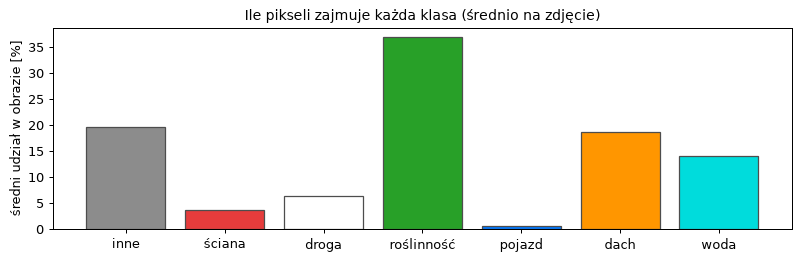

In [8]:
def lista_zdjec(katalog=KATALOG_VDD):
    """Tabela wszystkich zdjęć VDD: nazwa, oficjalny podział, numer klatki i udział klas [%] w masce."""
    wiersze = []
    for podzbior in ("train", "val", "test"):
        for plik in sorted((katalog / podzbior / "gt").glob("*.png")):
            maska = cv2.imread(str(plik), cv2.IMREAD_UNCHANGED)
            udzial = np.bincount(maska.ravel(), minlength=N_KLAS) / maska.size * 100
            wiersze.append({"nazwa": plik.stem, "oficjalny_podzial": podzbior, "nr": int(plik.stem.split("_")[1]),
                            **{f"{n}_proc": u for n, u in zip(NAZWY_KLAS, udzial)}})
    return pd.DataFrame(wiersze)


def sciezki(wiersz, katalog=KATALOG_VDD):
    """Ścieżki zdjęcia i maski. Pliki leżą w folderze oficjalnego podziału VDD."""
    p = katalog / wiersz["oficjalny_podzial"]
    return p / "src" / f"{wiersz['nazwa']}.JPG", p / "gt" / f"{wiersz['nazwa']}.png"


t0 = time.perf_counter()
df = lista_zdjec()
print(f"{len(df)} zdjęć, wczytano maski w {time.perf_counter() - t0:.0f} s")

srednie = df[[f"{n}_proc" for n in NAZWY_KLAS]].mean()
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(NAZWY_KLAS, srednie.values, color=KOLORY_KLAS, edgecolor="0.3")
ax.set_ylabel("średni udział w obrazie [%]")
ax.set_title("Ile pikseli zajmuje każda klasa (średnio na zdjęcie)")
plt.tight_layout(); plt.show()

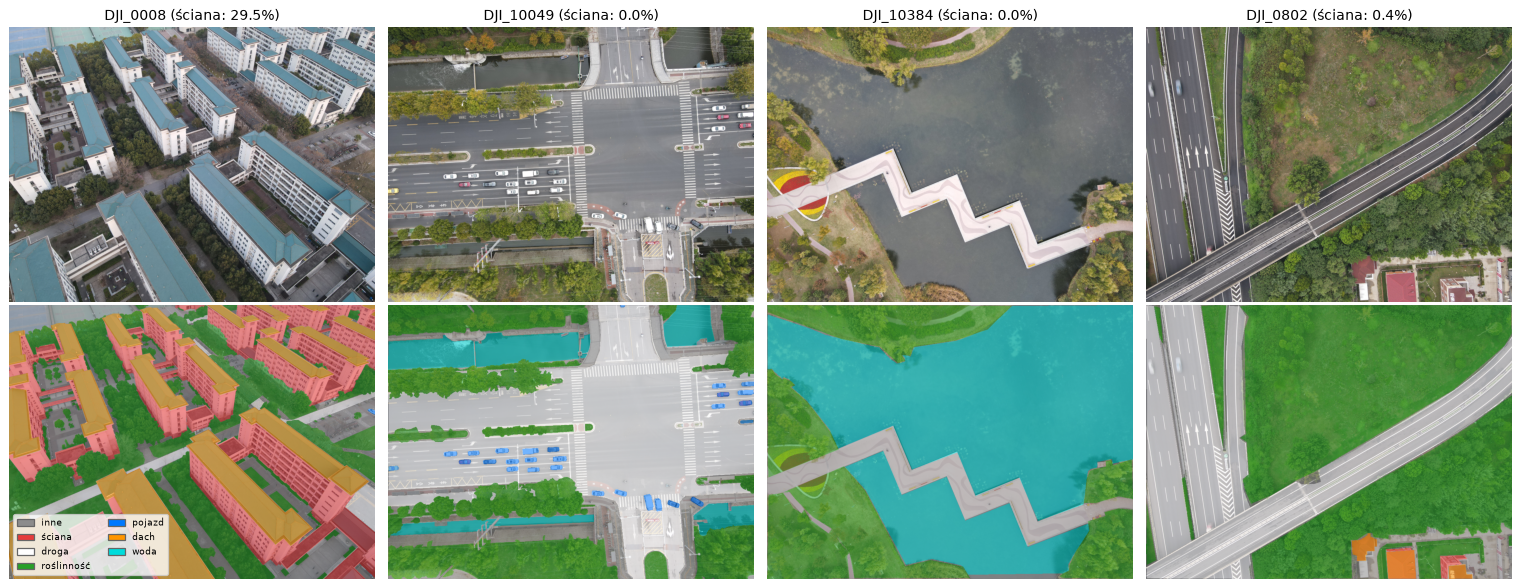

In [9]:
def nakladka_klas(rgb, maska, alfa=0.55):
    """Zdjęcie z półprzezroczystą maską klas (do oceny wzrokowej)."""
    return (1 - alfa) * rgb + alfa * KOLORY_RGB[maska]


def legenda():
    return [Patch(facecolor=k, edgecolor="0.4", label=n) for k, n in zip(KOLORY_KLAS, NAZWY_KLAS)]


def wczytaj_pelne(nazwa, maks_bok=1000):
    """Zdjęcie i maska zmniejszone tylko do wyświetlenia."""
    wiersz = df.set_index("nazwa").loc[nazwa].to_dict() | {"nazwa": nazwa}
    zdj, mas = sciezki(wiersz)
    rgb = cv2.cvtColor(cv2.imread(str(zdj)), cv2.COLOR_BGR2RGB)
    maska = cv2.imread(str(mas), cv2.IMREAD_UNCHANGED)
    f = maks_bok / max(rgb.shape[:2])
    rozmiar = (round(rgb.shape[1] * f), round(rgb.shape[0] * f))
    return cv2.resize(rgb, rozmiar, interpolation=cv2.INTER_AREA), cv2.resize(maska, rozmiar, interpolation=cv2.INTER_NEAREST)


PRZYKLADY = ["DJI_0008", "DJI_10049", "DJI_10384", "DJI_0802"]
fig, ax = plt.subplots(2, 4, figsize=(17, 6.6))
for k, nazwa in enumerate(PRZYKLADY):
    rgb, maska = wczytaj_pelne(nazwa)
    sciana = df.set_index("nazwa").loc[nazwa, "ściana_proc"]
    ax[0, k].imshow(rgb); ax[0, k].set_title(f"{nazwa} (ściana: {sciana:.1f}%)")
    ax[1, k].imshow(nakladka_klas(rgb, maska).astype(np.uint8))
    ax[0, k].axis("off"); ax[1, k].axis("off")
ax[1, 0].legend(handles=legenda(), loc="lower left", fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

Zdjęć z góry (ściana < 3.0%): 247 z 400
GSD z aut (66 zdjęć): mediana 3.5 cm, środkowe 50% zdjęć: 2.8–3.9 cm
Przyjmujemy GSD_VDD = 0.035 m → zmniejszamy zdjęcia 3.43× (4000×3000 → 1167×875 px), żeby uzyskać 12 cm/px


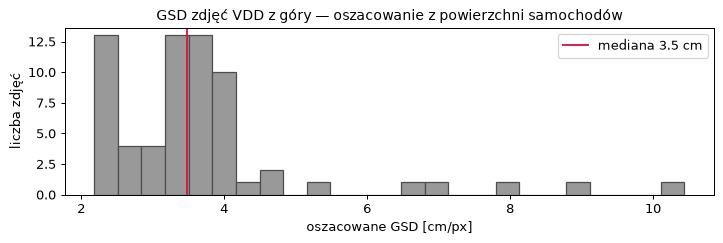

In [10]:
POW_AUTA_M2 = 8.0   # typowy samochód osobowy ≈ 4,4 m × 1,8 m


def gsd_z_aut(maska, min_pikseli=30, min_aut=5):
    """GSD [m/px] z mediany powierzchni obiektów klasy „pojazd"; None, gdy aut jest za mało."""
    _, _, stat, _ = cv2.connectedComponentsWithStats((maska == POJAZD).astype(np.uint8), connectivity=8)
    pola = stat[1:, cv2.CC_STAT_AREA]
    pola = pola[pola >= min_pikseli]                   # odrzucamy okruchy i fragmenty ucięte brzegiem
    return float(np.sqrt(POW_AUTA_M2 / np.median(pola))) if len(pola) >= min_aut else None


z_gora = df[df["ściana_proc"] < MAKS_SCIANA_PROC]
print(f"Zdjęć z góry (ściana < {MAKS_SCIANA_PROC}%): {len(z_gora)} z {len(df)}")

gsd_zdjec = {}
for _, w in z_gora[z_gora["pojazd_proc"] > 0.05].iterrows():
    g = gsd_z_aut(cv2.imread(str(sciezki(w)[1]), cv2.IMREAD_UNCHANGED))
    if g:
        gsd_zdjec[w["nazwa"]] = g
gsd_cm = np.array(list(gsd_zdjec.values())) * 100

GSD_VDD_M = round(float(np.median(gsd_cm)) / 100, 3)
SKALA = GSD_VDD_M / GSD_MODELU_M      # o tyle zmniejszamy zdjęcia VDD
print(f"GSD z aut ({len(gsd_cm)} zdjęć): mediana {np.median(gsd_cm):.1f} cm, "
      f"środkowe 50% zdjęć: {np.percentile(gsd_cm, 25):.1f}–{np.percentile(gsd_cm, 75):.1f} cm")
print(f"Przyjmujemy GSD_VDD = {GSD_VDD_M} m → zmniejszamy zdjęcia {1 / SKALA:.2f}× "
      f"(4000×3000 → {round(4000 * SKALA)}×{round(3000 * SKALA)} px), żeby uzyskać {GSD_MODELU_M * 100:.0f} cm/px")

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hist(gsd_cm, bins=25, color="0.6", edgecolor="0.3")
ax.axvline(np.median(gsd_cm), color="crimson", label=f"mediana {np.median(gsd_cm):.1f} cm")
ax.set_xlabel("oszacowane GSD [cm/px]"); ax.set_ylabel("liczba zdjęć"); ax.legend()
ax.set_title("GSD zdjęć VDD z góry — oszacowanie z powierzchni samochodów")
plt.tight_layout(); plt.show()

In [11]:
def dodaj_grupy(df, max_luka=5):
    """Kolumna 'grupa': klatki, których numery różnią się o ≤ max_luka, należą do jednego przelotu."""
    d = df.sort_values("nr").reset_index(drop=True)
    d["grupa"] = (d["nr"].diff().fillna(max_luka + 1) > max_luka).cumsum()
    return d


def podziel_po_grupach(d, cele=(0.70, 0.15, 0.15), proby=500, seed=SEED):
    """Przydziela grupy do train/val/test. Wybiera najlepszy z `proby` losowych przydziałów:
    liczebności blisko `cele`, a rozkład klas w val i test blisko rozkładu całości."""
    kolumny = [f"{n}_proc" for n in NAZWY_KLAS]
    rozmiary_grup = d.groupby("grupa").size()
    profile_grup = d.groupby("grupa")[kolumny].mean()
    srednia = d[kolumny].mean().to_numpy()
    cel = np.array(cele) * len(d)
    los = np.random.default_rng(seed)

    najlepszy = (np.inf, None)
    for _ in range(proby):
        przydzial, liczebnosc = {}, np.zeros(3)
        for g in los.permutation(rozmiary_grup.index.to_numpy()):
            k = int(np.argmax(cel - liczebnosc))               # zbiór z największym niedoborem zdjęć
            przydzial[g] = k
            liczebnosc[k] += rozmiary_grup[g]
        koszt = np.abs(liczebnosc - cel).sum() / len(d)
        for k in (1, 2):                                        # rozkład klas w val i test
            gs = [g for g, kk in przydzial.items() if kk == k]
            profil = np.average(profile_grup.loc[gs], axis=0, weights=rozmiary_grup[gs].to_numpy())
            koszt += np.abs(profil - srednia).sum() / 100
        if koszt < najlepszy[0]:
            najlepszy = (koszt, przydzial)

    wynik = d.copy()
    wynik["podzial"] = wynik["grupa"].map(najlepszy[1]).map({0: "train", 1: "val", 2: "test"})
    return wynik


df = dodaj_grupy(df)                                      # grupy liczymy na wszystkich 400 klatkach…
df_z_gory = df[df["ściana_proc"] < MAKS_SCIANA_PROC]      # …a dopiero potem zostawiamy ujęcia z góry
df_z_gory = podziel_po_grupach(df_z_gory)

# Kontrola: żadna grupa nie może trafić do dwóch zbiorów
assert df_z_gory.groupby("grupa")["podzial"].nunique().max() == 1

tabela = df_z_gory.groupby("podzial").agg(zdjec=("nazwa", "size"), grup=("grupa", "nunique"))
tabela = tabela.join(df_z_gory.groupby("podzial")[[f"{n}_proc" for n in NAZWY_KLAS]].mean().round(1)
                     .rename(columns=lambda c: c.replace("_proc", " %")))
tabela.loc[["train", "val", "test"]]

,zdjec,grup,inne %,ściana %,droga %,roślinność %,pojazd %,dach %,woda %
podzial,,,,,,,,,
train,177,19,17.2,0.5,6.0,38.5,0.2,11.9,25.5
val,35,9,19.6,0.9,7.8,38.5,0.9,14.4,17.9
test,35,7,22.4,0.7,7.7,37.4,1.0,27.3,3.6


Obraz 1167×875 px → 30 kafelków 256×256 (krok 192)


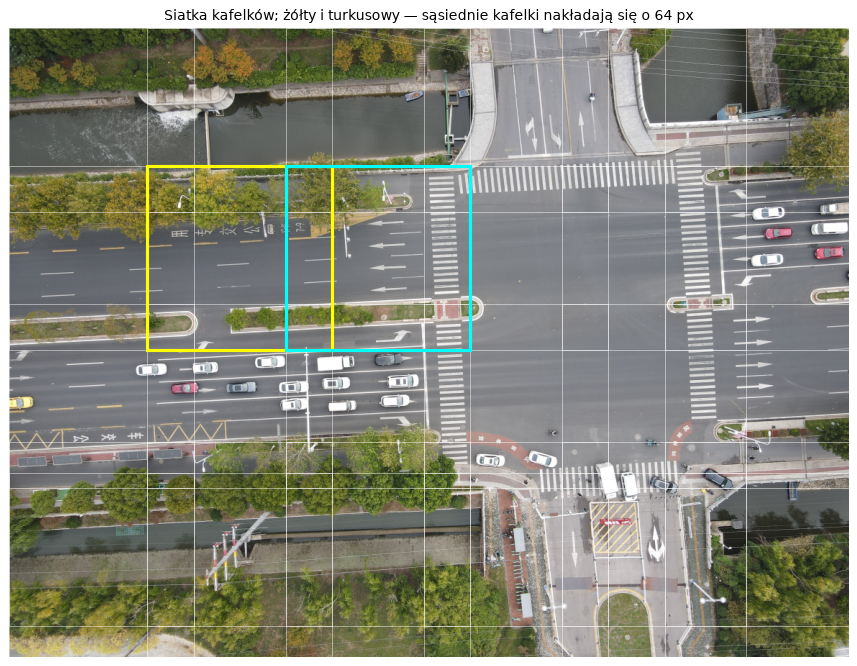

In [12]:
def siatka_kafelkow(wys, szer, rozmiar=KAFELEK, krok=KROK_TRENING):
    """Lista (y, x) lewych-górnych rogów kafelków pokrywających cały obraz."""
    def pozycje(n):
        if n <= rozmiar:
            return [0]
        p = list(range(0, n - rozmiar + 1, krok))
        if p[-1] != n - rozmiar:
            p.append(n - rozmiar)                         # ostatni kafelek dosunięty do krawędzi
        return p
    return [(y, x) for y in pozycje(wys) for x in pozycje(szer)]


rgb, maska = wczytaj_pelne("DJI_10049", maks_bok=round(4000 * SKALA))    # zdjęcie w skali 12 cm/px
kafelki = siatka_kafelkow(*rgb.shape[:2])
print(f"Obraz {rgb.shape[1]}×{rgb.shape[0]} px → {len(kafelki)} kafelków {KAFELEK}×{KAFELEK} (krok {KROK_TRENING})")

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.imshow(rgb)
for y, x in kafelki:
    ax.add_patch(Rectangle((x, y), KAFELEK, KAFELEK, fill=False, edgecolor="white", lw=0.6, alpha=0.6))
for (y, x), kolor in zip([kafelki[7], kafelki[8]], ["yellow", "cyan"]):       # dwa sąsiednie — widać nakładanie
    ax.add_patch(Rectangle((x, y), KAFELEK, KAFELEK, fill=False, edgecolor=kolor, lw=2.5))
ax.set_title("Siatka kafelków; żółty i turkusowy — sąsiednie kafelki nakładają się o 64 px"); ax.axis("off")
plt.tight_layout(); plt.show()

In [13]:
SREDNIA = np.array([0.485, 0.456, 0.406], dtype=np.float32)      # statystyki ImageNet — na nich uczono enkoder
ODCHYLENIE = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def do_tensora(rgb):
    """RGB uint8 (H,W,3) → tensor float32 (3,H,W) znormalizowany jak w ImageNet."""
    return torch.from_numpy(((rgb.astype(np.float32) / 255 - SREDNIA) / ODCHYLENIE).transpose(2, 0, 1).copy())


def z_tensora(t):
    return np.clip((t.numpy().transpose(1, 2, 0) * ODCHYLENIE + SREDNIA) * 255, 0, 255).astype(np.uint8)


def wczytaj_zmniejszone(wiersz, skala=SKALA):
    zdj, mas = sciezki(wiersz)
    rgb = cv2.cvtColor(cv2.imread(str(zdj)), cv2.COLOR_BGR2RGB)
    maska = cv2.imread(str(mas), cv2.IMREAD_UNCHANGED)
    assert rgb.shape[:2] == maska.shape, f"{wiersz['nazwa']}: zdjęcie i maska mają różne rozmiary"
    rozmiar = (round(rgb.shape[1] * skala), round(rgb.shape[0] * skala))
    return (cv2.resize(rgb, rozmiar, interpolation=cv2.INTER_AREA),
            cv2.resize(maska, rozmiar, interpolation=cv2.INTER_NEAREST))


t0 = time.perf_counter()
with ThreadPoolExecutor(8) as pula:
    wczytane = list(pula.map(wczytaj_zmniejszone, [w for _, w in df_z_gory.iterrows()]))
OBRAZY = dict(zip(df_z_gory["nazwa"], wczytane))
print(f"{len(OBRAZY)} zdjęć w skali {SKALA:.3f}: {sum(r.nbytes + m.nbytes for r, m in wczytane) / 1e9:.2f} GB, "
      f"{time.perf_counter() - t0:.0f} s")

247 zdjęć w skali 0.292: 1.01 GB, 4 s


In [14]:
ZAKRES_SKALI = (0.75, 1.3)     # losowa zmiana skali przy uczeniu


def augmentuj(rgb, maska, rng):
    """Okno dowolnego rozmiaru → kafelek KAFELEK×KAFELEK po losowym obrocie, odbiciu i zmianie barw."""
    if rgb.shape[0] != KAFELEK:                               # zmiana skali: okno większe/mniejsze niż kafelek
        rgb = cv2.resize(rgb, (KAFELEK, KAFELEK), interpolation=cv2.INTER_AREA if rgb.shape[0] > KAFELEK else cv2.INTER_LINEAR)
        maska = cv2.resize(maska, (KAFELEK, KAFELEK), interpolation=cv2.INTER_NEAREST)
    n = int(rng.integers(4))
    rgb, maska = np.rot90(rgb, n), np.rot90(maska, n)
    if rng.random() < 0.5:
        rgb, maska = rgb[:, ::-1], maska[:, ::-1]
    kontrast, jasnosc, barwa = rng.uniform(0.75, 1.25), rng.uniform(-25, 25), rng.uniform(0.92, 1.08, size=3)
    rgb = np.clip(rgb.astype(np.float32) * kontrast * barwa + jasnosc, 0, 255).astype(np.uint8)
    return np.ascontiguousarray(rgb), np.ascontiguousarray(maska)


class KafelkiDataset(Dataset):
    """Kafelki KAFELEK×KAFELEK ze zdjęć `nazwy`; z augmentacją dla zbioru uczącego."""

    def __init__(self, nazwy, krok, augmentacja=False, seed=SEED):
        self.obrazy = [OBRAZY[n] for n in nazwy]
        self.kafelki = [(i, y, x) for i, (rgb, _) in enumerate(self.obrazy)
                        for y, x in siatka_kafelkow(*rgb.shape[:2], KAFELEK, krok)]
        self.augmentacja = augmentacja
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.kafelki)

    def __getitem__(self, idx):
        i, y, x = self.kafelki[idx]
        rgb, maska = self.obrazy[i]
        if self.augmentacja:
            k = min(round(KAFELEK / self.rng.uniform(*ZAKRES_SKALI)), *rgb.shape[:2])    # rozmiar okna wokół kafelka
            y0 = int(np.clip(y + KAFELEK // 2 - k // 2, 0, rgb.shape[0] - k))
            x0 = int(np.clip(x + KAFELEK // 2 - k // 2, 0, rgb.shape[1] - k))
            rgb, maska = augmentuj(rgb[y0:y0 + k, x0:x0 + k], maska[y0:y0 + k, x0:x0 + k], self.rng)
        else:
            rgb, maska = rgb[y:y + KAFELEK, x:x + KAFELEK], maska[y:y + KAFELEK, x:x + KAFELEK]
        return do_tensora(rgb), torch.from_numpy(maska.astype(np.int64))

kafelki: uczące 5310, walidacyjne 700  →  165 kroków na epokę


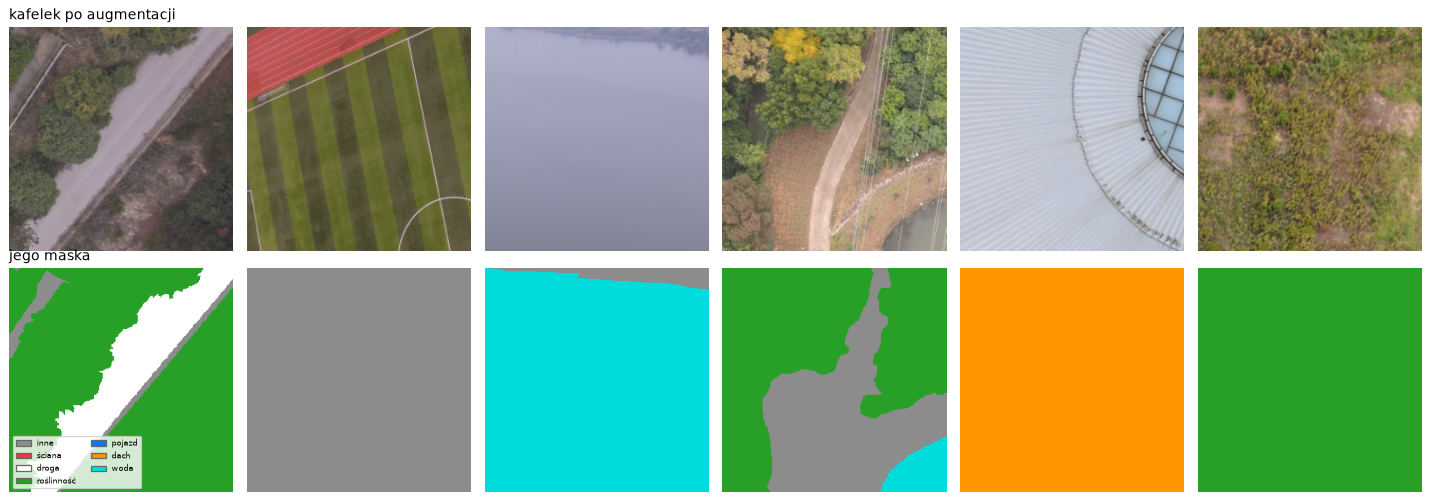

In [15]:
nazwy = {p: df_z_gory.loc[df_z_gory["podzial"] == p, "nazwa"].tolist() for p in ("train", "val", "test")}

ds_train = KafelkiDataset(nazwy["train"], krok=KROK_TRENING, augmentacja=True)
ds_val = KafelkiDataset(nazwy["val"], krok=KAFELEK)            # walidacja: kafelki bez nakładania i bez augmentacji
dl_train = DataLoader(ds_train, batch_size=ROZMIAR_PACZKI, shuffle=True, drop_last=True,
                      generator=torch.Generator().manual_seed(SEED))
dl_val = DataLoader(ds_val, batch_size=ROZMIAR_PACZKI)
print(f"kafelki: uczące {len(ds_train)}, walidacyjne {len(ds_val)}  →  {len(dl_train)} kroków na epokę")

fig, ax = plt.subplots(2, 6, figsize=(16, 5.6))
for k, idx in enumerate(np.random.default_rng(1).choice(len(ds_train), 6, replace=False)):
    x, y = ds_train[idx]
    ax[0, k].imshow(z_tensora(x)); ax[1, k].imshow(KOLORY_RGB[y.numpy()])
    ax[0, k].axis("off"); ax[1, k].axis("off")
ax[0, 0].set_title("kafelek po augmentacji", loc="left"); ax[1, 0].set_title("jego maska", loc="left")
ax[1, 0].legend(handles=legenda(), loc="lower left", fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

In [16]:
def zbuduj_model(wagi_enkodera="imagenet"):
    return smp.Unet(encoder_name="resnet34", encoder_weights=wagi_enkodera, in_channels=3, classes=N_KLAS)


def wagi_klas(nazwy_uczace):
    """Waga klasy ~ 1/√(jej udział w pikselach) — rzadkie klasy liczą się bardziej. Średnia waga = 1."""
    liczniki = sum(np.bincount(OBRAZY[n][1].ravel(), minlength=N_KLAS) for n in nazwy_uczace).astype(float)
    w = 1 / np.sqrt(liczniki / liczniki.sum())
    return liczniki / liczniki.sum() * 100, torch.tensor(w / w.mean(), dtype=torch.float32)


UDZIALY_UCZACE, WAGI_KLAS = wagi_klas(nazwy["train"])
pd.DataFrame({"udział w zbiorze uczącym [%]": UDZIALY_UCZACE, "waga w stracie": WAGI_KLAS.numpy()},
             index=NAZWY_KLAS).round(2).T

,inne,ściana,droga,roślinność,pojazd,dach,woda
udział w zbiorze uczącym [%],17.22,0.54,6.00,38.53,0.25,11.92,25.53
waga w stracie,0.36,2.04,0.61,0.24,3.01,0.43,0.30


In [17]:
def macierz_pomylek(prawda, predykcja):
    """Macierz N_KLAS×N_KLAS: wiersze = klasa prawdziwa, kolumny = przewidziana."""
    idx = N_KLAS * np.asarray(prawda, dtype=np.int64).ravel() + np.asarray(predykcja, dtype=np.int64).ravel()
    return np.bincount(idx, minlength=N_KLAS ** 2).reshape(N_KLAS, N_KLAS)


def metryki(cm):
    """IoU i F1 dla każdej klasy (NaN, gdy klasy nie ma ani w prawdzie, ani w predykcji)."""
    tp = np.diag(cm).astype(float)
    fp, fn = cm.sum(0) - tp, cm.sum(1) - tp
    with np.errstate(divide="ignore", invalid="ignore"):
        return pd.DataFrame({"IoU": tp / (tp + fp + fn), "F1": 2 * tp / (2 * tp + fp + fn),
                             "udział w prawdzie [%]": cm.sum(1) / cm.sum() * 100}, index=NAZWY_KLAS)


def podsumowanie(cm):
    m = metryki(cm)
    return {"mIoU": m["IoU"].mean(), "F1 (średnia z klas)": m["F1"].mean(), "dokładność pikselowa": np.trace(cm) / cm.sum()}


# Przykład: „model", który nigdy nie widzi pojazdów, na obrazie z 2% pojazdów
prawda = np.zeros(1000, dtype=int); prawda[:20] = POJAZD
cm = macierz_pomylek(prawda, np.zeros(1000, dtype=int))
print(f"dokładność pikselowa {np.trace(cm) / cm.sum():.0%}, ale IoU pojazdu = {metryki(cm).loc['pojazd', 'IoU']:.2f}")

dokładność pikselowa 98%, ale IoU pojazdu = 0.00


In [27]:
@torch.no_grad()
def ocen_na_kafelkach(model, dl):
    model.eval()
    cm = np.zeros((N_KLAS, N_KLAS), dtype=np.int64)
    for x, y in dl:
        cm += macierz_pomylek(y.numpy(), model(x.to(URZADZENIE)).argmax(1).cpu().numpy())
    return cm


def zapisz_checkpoint(plik, **stan):
    tmp = plik.with_name(plik.name + ".tmp")
    torch.save(stan, tmp)
    tmp.replace(plik)                      # podmiana na końcu: przerwanie w trakcie zapisu nie psuje poprzedniego checkpointu

EPOKI = 3
def trenuj(model, dl_train, dl_val, epoki=EPOKI, lr=1e-3, plik_checkpointu=None, od_wag=False, epoka0=0):
    """Uczy model i zwraca historię; na końcu w modelu zostaje wersja z najlepszym mIoU na walidacji.

    plik_checkpointu: po każdej epoce zapisujemy w nim pełny stan uczenia; jeśli plik już istnieje (trening przerwano),
        wczytujemy go i kontynuujemy od następnej epoki. Po skończonym treningu plik jest usuwany.
    od_wag: model ma już wagi (douczanie) — do pobicia jest jego mIoU sprzed uczenia, więc wynik się nie pogorszy.
    epoka0: liczba epok wykonanych wcześniej — od niej numerujemy epoki w historii.
    """
    model.to(URZADZENIE)
    ce = nn.CrossEntropyLoss(weight=WAGI_KLAS.to(URZADZENIE))
    dice = smp.losses.DiceLoss("multiclass")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    plan = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epoki * len(dl_train), pct_start=0.15)
    ustawienia = {"epoki": epoki, "lr": lr, "kroki_na_epoke": len(dl_train)}
    historia, najlepszy_miou, najlepszy_stan, pierwsza = [], -1.0, None, 1
    if plik_checkpointu is not None and plik_checkpointu.exists():
        ck = torch.load(plik_checkpointu, map_location="cpu", weights_only=True)
        if ck["ustawienia"] != ustawienia:
            raise ValueError(f"{plik_checkpointu.name} pochodzi z treningu o innych ustawieniach: {ck['ustawienia']}, "
                             f"a teraz jest {ustawienia}. Przywróć ustawienia albo usuń ten plik.")
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"]); plan.load_state_dict(ck["plan"])
        dl_train.generator.set_state(ck["kolejnosc_paczek"])                    # losowość jak w nieprzerwanym treningu
        dl_train.dataset.rng.bit_generator.state = ck["augmentacja"]
        historia, najlepszy_miou, najlepszy_stan = ck["historia"], ck["najlepszy_miou"], ck["najlepszy_stan"]
        pierwsza = ck["epoka"] + 1
        print(f"Wczytano checkpoint {plik_checkpointu.name}: gotowe {ck['epoka']}/{epoki} epok, kontynuuję od {pierwsza}.")
    elif od_wag:
        najlepszy_miou = float(metryki(ocen_na_kafelkach(model, dl_val))["IoU"].mean())
        najlepszy_stan = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"Douczanie od wczytanych wag: val mIoU {najlepszy_miou:.3f} (tyle trzeba pobić)")
    for epoka in range(pierwsza, epoki + 1):
        t0 = time.perf_counter()
        model.train()
        straty = []
        for x, y in dl_train:
            x, y = x.to(URZADZENIE), y.to(URZADZENIE)
            opt.zero_grad(set_to_none=True)
            wyjscie = model(x)
            strata = ce(wyjscie, y) + dice(wyjscie, y)
            strata.backward()
            opt.step()
            plan.step()
            straty.append(strata.item())
        m = metryki(ocen_na_kafelkach(model, dl_val))
        miou, f1 = float(m["IoU"].mean()), float(m["F1"].mean())
        historia.append({"epoka": epoka0 + epoka, "strata_uczenia": float(np.mean(straty)), "val_mIoU": miou, "val_F1": f1})
        if miou > najlepszy_miou:
            najlepszy_miou = miou
            najlepszy_stan = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoka {epoka:2d}/{epoki} | strata {np.mean(straty):.3f} | val mIoU {miou:.3f}, F1 {f1:.3f} "
              f"| {time.perf_counter() - t0:.0f} s")
        if plik_checkpointu is not None:
            zapisz_checkpoint(plik_checkpointu, ustawienia=ustawienia, epoka=epoka, model=model.state_dict(),
                              opt=opt.state_dict(), plan=plan.state_dict(), historia=historia,
                              najlepszy_miou=najlepszy_miou, najlepszy_stan=najlepszy_stan,
                              kolejnosc_paczek=dl_train.generator.get_state(),
                              augmentacja=dl_train.dataset.rng.bit_generator.state)
    model.load_state_dict(najlepszy_stan)
    if plik_checkpointu is not None:
        plik_checkpointu.unlink(missing_ok=True)                  # trening skończony — checkpoint nie jest już potrzebny
    return pd.DataFrame(historia)


PLIK_HISTORII = PLIK_MODELU.with_suffix(".csv")
PLIK_CHECKPOINTU = PLIK_MODELU.with_name(PLIK_MODELU.stem + "_checkpoint.pt")                    # trening w toku
PLIK_CHECKPOINTU_DOUCZANIA = PLIK_MODELU.with_name(PLIK_MODELU.stem + "_checkpoint_douczanie.pt")


def zapisz_model(model, historia):
    torch.save({"state_dict": model.state_dict(), "klasy": NAZWY_KLAS, "gsd_m": GSD_MODELU_M, "kafelek": KAFELEK}, PLIK_MODELU)
    historia.to_csv(PLIK_HISTORII, index=False)
    print(f"Zapisano model: {PLIK_MODELU} ({PLIK_MODELU.stat().st_size / 1e6:.0f} MB)")


if TRENUJ or not PLIK_MODELU.exists():
    model = zbuduj_model()
    historia = trenuj(model, dl_train, dl_val, plik_checkpointu=PLIK_CHECKPOINTU)   # jeśli jest checkpoint, wznawia z niego
    zapisz_model(model, historia)
else:
    zapis = torch.load(PLIK_MODELU, map_location="cpu", weights_only=True)
    model = zbuduj_model(wagi_enkodera=None)                   # wagi i tak nadpiszemy zapisanymi
    model.load_state_dict(zapis["state_dict"])
    historia = pd.read_csv(PLIK_HISTORII)
    print(f"Wczytano model z {PLIK_MODELU} (GSD {zapis['gsd_m']} m, kafelek {zapis['kafelek']} px)")

if EPOKI_DOUCZANIA:
    dodatkowa = trenuj(model, dl_train, dl_val, epoki=EPOKI_DOUCZANIA, lr=LR_DOUCZANIA, od_wag=True,
                       plik_checkpointu=PLIK_CHECKPOINTU_DOUCZANIA, epoka0=len(historia))
    historia = pd.concat([historia, dodatkowa], ignore_index=True)
    zapisz_model(model, historia)
model.to(URZADZENIE).eval();

epoka  1/3 | strata 1.600 | val mIoU 0.384, F1 0.490 | 61 s
epoka  2/3 | strata 1.026 | val mIoU 0.490, F1 0.614 | 64 s
epoka  3/3 | strata 0.821 | val mIoU 0.542, F1 0.671 | 82 s
Zapisano model: modele/unet_vdd_resnet34.pt (98 MB)


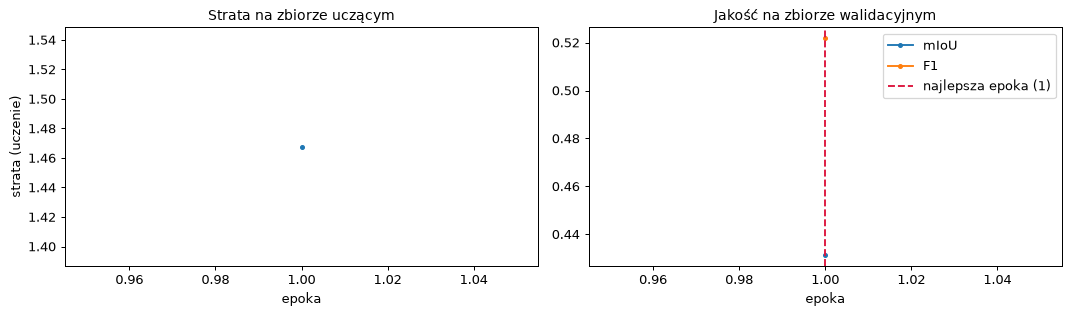

In [23]:
najlepsza = historia["val_mIoU"].idxmax()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(historia["epoka"], historia["strata_uczenia"], marker="o", ms=3)
ax[0].set_xlabel("epoka"); ax[0].set_ylabel("strata (uczenie)"); ax[0].set_title("Strata na zbiorze uczącym")
ax[1].plot(historia["epoka"], historia["val_mIoU"], marker="o", ms=3, label="mIoU")
ax[1].plot(historia["epoka"], historia["val_F1"], marker="o", ms=3, label="F1")
ax[1].axvline(historia.loc[najlepsza, "epoka"], color="crimson", ls="--", label=f"najlepsza epoka ({historia.loc[najlepsza, 'epoka']})")
ax[1].set_xlabel("epoka"); ax[1].set_title("Jakość na zbiorze walidacyjnym"); ax[1].legend()
plt.tight_layout(); plt.show()

In [24]:
def okno_hanna(rozmiar):
    w = np.hanning(rozmiar + 2)[1:-1].astype(np.float32)        # bez zer na brzegach
    return np.outer(w, w)


@torch.no_grad()
def predykcja_kafelkami(model, rgb, kafelek=KAFELEK, krok=KAFELEK // 2, paczka=16, tta=True):
    """Prawdopodobieństwa klas (N_KLAS, H, W) dla obrazu RGB uint8 dowolnego rozmiaru."""
    model.eval()
    h, w = rgb.shape[:2]
    if h < kafelek or w < kafelek:                              # obraz mniejszy niż kafelek — dopełniamy
        rgb = cv2.copyMakeBorder(rgb, 0, max(0, kafelek - h), 0, max(0, kafelek - w), cv2.BORDER_REPLICATE)
    H, W = rgb.shape[:2]
    suma = np.zeros((N_KLAS, H, W), dtype=np.float32)
    waga = np.zeros((H, W), dtype=np.float32)
    okno = okno_hanna(kafelek)
    pozycje = siatka_kafelkow(H, W, kafelek, krok)              # to samo cięcie co przy uczeniu
    for i in range(0, len(pozycje), paczka):
        poz = pozycje[i:i + paczka]
        x = torch.stack([do_tensora(rgb[y:y + kafelek, xx:xx + kafelek]) for y, xx in poz]).to(URZADZENIE)
        p = model(x).softmax(1)
        if tta:
            p = (p + model(x.flip(-1)).softmax(1).flip(-1)) / 2      # odbicie poziome i z powrotem
        for (y, xx), pk in zip(poz, p.cpu().numpy()):
            suma[:, y:y + kafelek, xx:xx + kafelek] += pk * okno
            waga[y:y + kafelek, xx:xx + kafelek] += okno
    return (suma / waga)[:, :h, :w]


def ocen_na_obrazach(model, nazwy_obrazow):
    cm = np.zeros((N_KLAS, N_KLAS), dtype=np.int64)
    predykcje = {}
    for n in nazwy_obrazow:
        rgb, maska = OBRAZY[n]
        predykcje[n] = predykcja_kafelkami(model, rgb).argmax(0).astype(np.uint8)
        cm += macierz_pomylek(maska, predykcje[n])
    return cm, predykcje


t0 = time.perf_counter()
cm_test, pred_test = ocen_na_obrazach(model, nazwy["test"])
print(f"Zbiór testowy: {len(nazwy['test'])} zdjęć, {time.perf_counter() - t0:.0f} s")
print({k: round(float(v), 3) for k, v in podsumowanie(cm_test).items()})
metryki(cm_test).round(3)

Zbiór testowy: 35 zdjęć, 12 s
{'mIoU': 0.339, 'F1 (średnia z klas)': 0.444, 'dokładność pikselowa': 0.621}


,IoU,F1,udział w prawdzie [%]
inne,0.278,0.435,22.360
ściana,0.005,0.009,0.651
droga,0.455,0.625,7.729
roślinność,0.785,0.880,37.428
pojazd,0.000,0.000,0.995
dach,0.269,0.424,27.265
woda,0.582,0.736,3.573


In [28]:
def roslinnosc_exg_otsu(rgb):
    """Metoda z poziomu 1: ExG na współrzędnych chromatycznych + próg Otsu (liczony osobno dla każdego zdjęcia)."""
    R, G, B = (rgb[..., i].astype(np.float32) for i in range(3))
    exg = (2 * G - R - B) / (R + G + B + 1e-6)
    return exg > threshold_otsu(exg)


ROSLINNOSC = NAZWY_KLAS.index("roślinność")
tp = fp = fn = 0
for n in nazwy["test"]:
    rgb, maska = OBRAZY[n]
    prawda, exg = maska == ROSLINNOSC, roslinnosc_exg_otsu(rgb)
    tp += (prawda & exg).sum(); fp += (~prawda & exg).sum(); fn += (prawda & ~exg).sum()

m = metryki(cm_test).loc["roślinność"]
pd.DataFrame({"IoU": [tp / (tp + fp + fn), m["IoU"]], "F1": [2 * tp / (2 * tp + fp + fn), m["F1"]]},
             index=["ExG + Otsu (poziom 1, bez uczenia)", "U-Net (poziom 3)"]).round(3)

,IoU,F1
"ExG + Otsu (poziom 1, bez uczenia)",0.485,0.653
U-Net (poziom 3),0.785,0.880


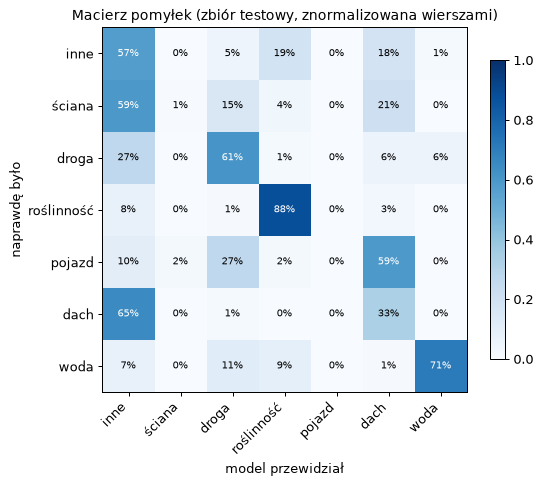

In [36]:
cm_norm = cm_test / cm_test.sum(1, keepdims=True)            # wiersz = klasa prawdziwa; komórka = jaki odsetek poszedł gdzie
fig, ax = plt.subplots(figsize=(6.4, 5.4))
obraz = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(N_KLAS), NAZWY_KLAS, rotation=45, ha="right"); ax.set_yticks(range(N_KLAS), NAZWY_KLAS)
for i in range(N_KLAS):
    for j in range(N_KLAS):
        ax.text(j, i, f"{cm_norm[i, j]:.0%}", ha="center", va="center", fontsize=8,
                color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set_xlabel("model przewidział"); ax.set_ylabel("naprawdę było")
ax.set_title("Macierz pomyłek (zbiór testowy, znormalizowana wierszami)")
plt.colorbar(obraz, shrink=0.8); plt.tight_layout(); plt.show()

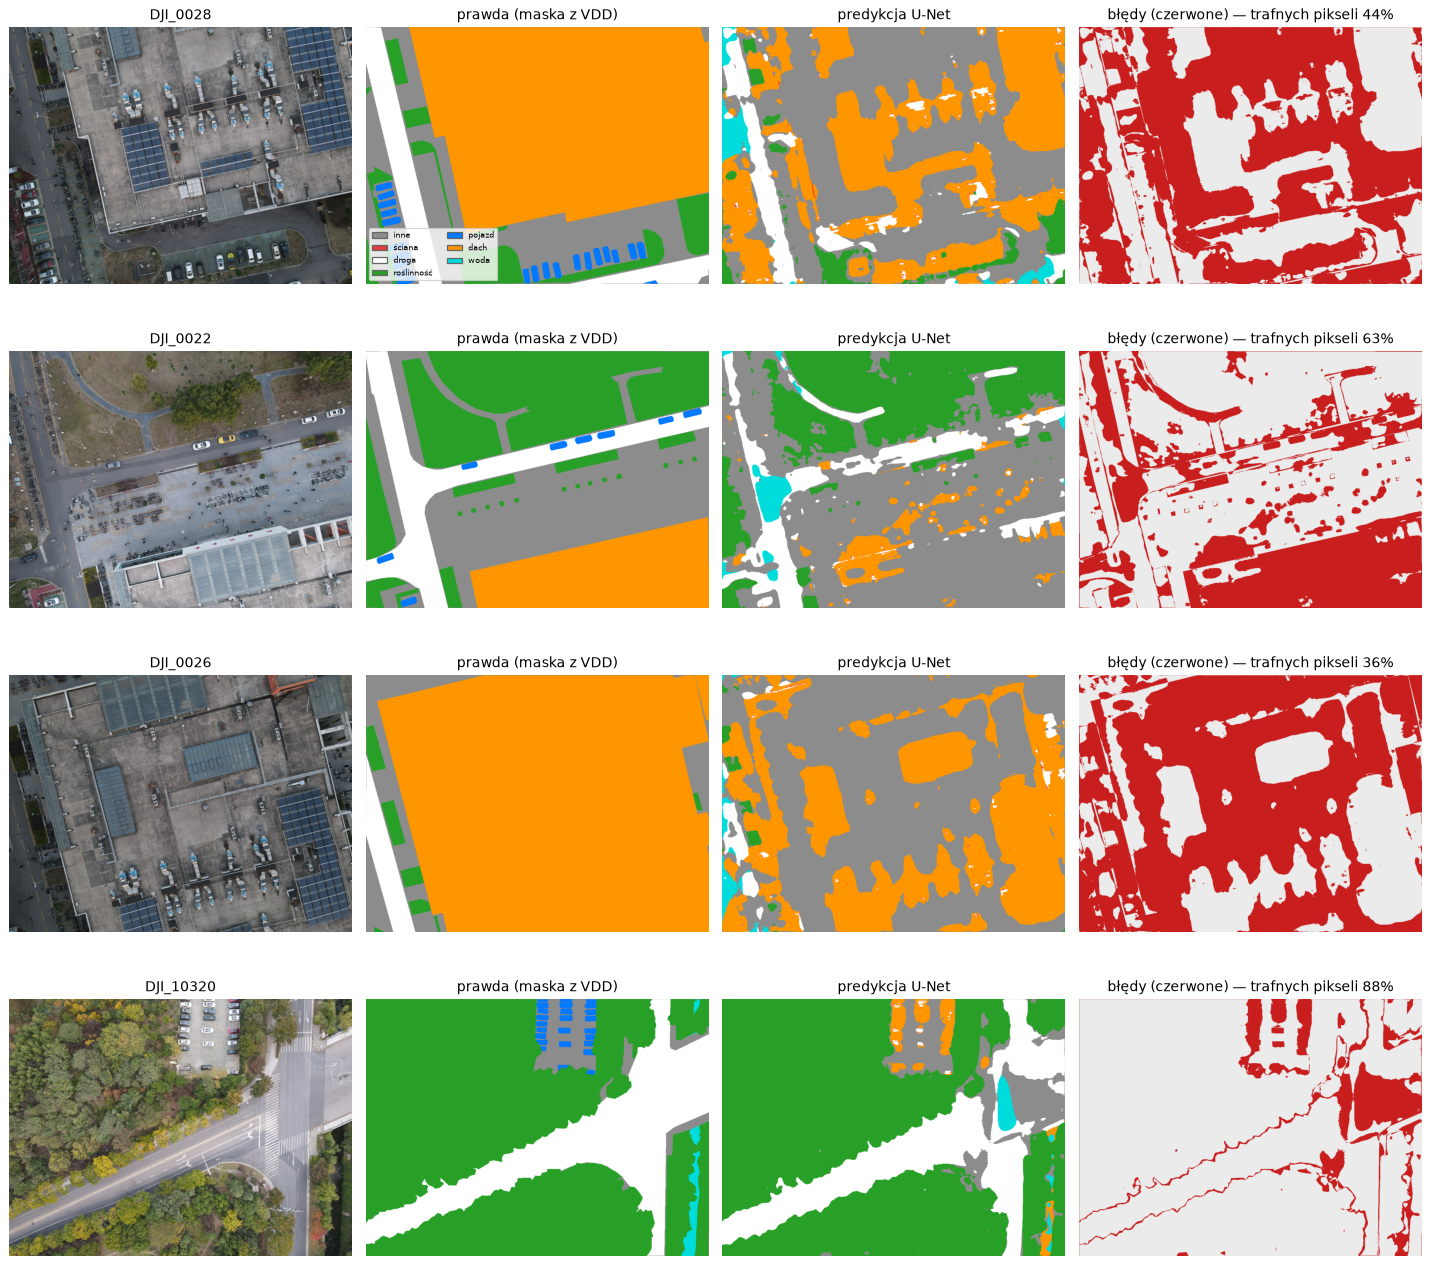

In [37]:
def panel_wynikow(nazwy_obrazow, predykcje):
    fig, ax = plt.subplots(len(nazwy_obrazow), 4, figsize=(16, 3.7 * len(nazwy_obrazow)))
    for w, n in enumerate(nazwy_obrazow):
        rgb, prawda = OBRAZY[n]
        pred = predykcje[n]
        trafienie = (pred == prawda).mean()
        ax[w, 0].imshow(rgb); ax[w, 0].set_title(f"{n}")
        ax[w, 1].imshow(KOLORY_RGB[prawda]); ax[w, 1].set_title("prawda (maska z VDD)")
        ax[w, 2].imshow(KOLORY_RGB[pred]); ax[w, 2].set_title("predykcja U-Net")
        blad = np.full((*prawda.shape, 3), 235, dtype=np.uint8)
        blad[pred != prawda] = (200, 30, 30)
        ax[w, 3].imshow(blad); ax[w, 3].set_title(f"błędy (czerwone) — trafnych pikseli {trafienie:.0%}")
        for a in ax[w]:
            a.axis("off")
    ax[0, 1].legend(handles=legenda(), loc="lower left", fontsize=6, ncol=2)
    plt.tight_layout(); plt.show()


# zdjęcia losowe, nie dobrane pod efekt
panel_wynikow(list(np.random.default_rng(3).choice(nazwy["test"], 4, replace=False)), pred_test)

In [33]:
def segmentuj_ortomozaik(sciezka_wej, sciezka_klas, sciezka_pewnosci, model, blok=1024, margines=128):
    """RGB GeoTIFF → GeoTIFF z klasami (uint8, 255 = brak danych) i GeoTIFF z pewnością (0–100).
    Zwraca liczbę pikseli każdej klasy i GSD ortomozaiku."""
    with rasterio.open(sciezka_wej) as src:
        if src.count < 3 or src.dtypes[0] != "uint8":
            raise ValueError(f"Oczekuję 8-bitowego RGB, a jest: {src.count} pasm, {src.dtypes[0]}")
        if src.crs is None or not src.crs.is_projected:
            raise ValueError("Ortomozaik musi mieć układ metryczny (np. UTM, PL-2000) — inaczej nie znamy GSD.")
        gsd = src.res[0]
        if abs(gsd / GSD_MODELU_M - 1) > 0.25:
            raise ValueError(f"GSD ortomozaiku to {gsd:.3f} m, a model uczyliśmy w {GSD_MODELU_M} m — "
                             "najpierw zmień rozdzielczość ortomozaiku.")
        profil = dict(driver="GTiff", height=src.height, width=src.width, count=1, dtype="uint8", crs=src.crs,
                      transform=src.transform, nodata=255, compress="deflate", tiled=True, blockxsize=256, blockysize=256)
        piksele = np.zeros(N_KLAS, dtype=np.int64)

        with rasterio.open(sciezka_klas, "w", **profil) as wyj_klasy, rasterio.open(sciezka_pewnosci, "w", **profil) as wyj_pewn:
            for y0 in range(0, src.height, blok):
                for x0 in range(0, src.width, blok):
                    szer, wys = min(blok, src.width - x0), min(blok, src.height - y0)
                    x1, y1 = max(0, x0 - margines), max(0, y0 - margines)                 # blok z marginesem
                    x2, y2 = min(src.width, x0 + szer + margines), min(src.height, y0 + wys + margines)
                    rgb = np.moveaxis(src.read([1, 2, 3], window=Window(x1, y1, x2 - x1, y2 - y1)), 0, -1)
                    p = predykcja_kafelkami(model, rgb)
                    w = np.s_[y0 - y1:y0 - y1 + wys, x0 - x1:x0 - x1 + szer]              # wycinamy sam blok, bez marginesu
                    waznie = ~(rgb[w] == 0).all(axis=-1)                                  # czarne tło = brak danych
                    klasy = np.where(waznie, p.argmax(0)[w], 255).astype(np.uint8)
                    pewnosc = np.where(waznie, np.round(p.max(0)[w] * 100), 255).astype(np.uint8)
                    okno = Window(x0, y0, szer, wys)
                    wyj_klasy.write(klasy, 1, window=okno)
                    wyj_pewn.write(pewnosc, 1, window=okno)
                    piksele += np.bincount(klasy[waznie], minlength=N_KLAS)
            wyj_klasy.write_colormap(1, {i: (*map(int, kolor), 255) for i, kolor in enumerate(KOLORY_RGB)})
    return piksele, gsd


WYJ_KLASY = KATALOG_WYNIKOW / "tapias_klasy.tif"
WYJ_PEWNOSC = KATALOG_WYNIKOW / "tapias_pewnosc.tif"
ORTOMOZAIK = Path("data/tapias_ortofoto.tif") 
t0 = time.perf_counter()
piksele, gsd = segmentuj_ortomozaik(ORTOMOZAIK, WYJ_KLASY, WYJ_PEWNOSC, model)
print(f"Gotowe w {time.perf_counter() - t0:.0f} s → {WYJ_KLASY}, {WYJ_PEWNOSC}")

pd.DataFrame({"powierzchnia [ha]": piksele * gsd ** 2 / 1e4, "udział [%]": piksele / piksele.sum() * 100},
             index=NAZWY_KLAS).round(2)

Gotowe w 2 s → wyniki/tapias_klasy.tif, wyniki/tapias_pewnosc.tif


,powierzchnia [ha],udział [%]
inne,0.90,22.59
ściana,0.23,5.80
droga,0.00,0.05
roślinność,2.81,70.37
pojazd,0.00,0.11
dach,0.04,1.06
woda,0.00,0.03


In [34]:
with rasterio.open(ORTOMOZAIK) as a, rasterio.open(WYJ_KLASY) as b:
    assert a.crs == b.crs and a.transform == b.transform and a.shape == b.shape, "wynik nie leży na siatce zdjęcia!"
    print(f"CRS: {b.crs} | siatka {b.width}×{b.height} px | piksel {b.res[0]:.3f} m | zasięg: {tuple(round(v, 1) for v in b.bounds)}")
    print("lewy górny róg piksela (0, 0) — zdjęcie:", a.xy(0, 0), "| wynik:", b.xy(0, 0))
    rgb = np.moveaxis(a.read([1, 2, 3]), 0, -1)
    klasy = b.read(1)
with rasterio.open(WYJ_PEWNOSC) as c:
    pewnosc = c.read(1)

waznie = klasy != 255
calosc = predykcja_kafelkami(model, rgb).argmax(0)
zgodnosc = (calosc[waznie] == klasy[waznie]).mean()
print(f"Zgodność z predykcją całego ortomozaiku naraz: {zgodnosc:.2%} pikseli")

# Blok 1024 i margines 128 są wielokrotnościami kroku kafelków (128), więc siatki kafelków się pokrywają.
# A gdyby nie pasowały? Ten sam ortomozaik z blokiem 1000 i marginesem 100:
with tempfile.TemporaryDirectory() as tmp:
    segmentuj_ortomozaik(ORTOMOZAIK, Path(tmp) / "k.tif", Path(tmp) / "p.tif", model, blok=1000, margines=100)
    with rasterio.open(Path(tmp) / "k.tif") as src:
        inne_bloki = src.read(1)
print(f"Zgodność przy niedopasowanych blokach (1000 px, margines 100): {(inne_bloki[waznie] == klasy[waznie]).mean():.2%}")

CRS: EPSG:32618 | siatka 1731×1731 px | piksel 0.120 m | zasięg: (460977.9, 492238.4, 461185.6, 492446.2)
lewy górny róg piksela (0, 0) — zdjęcie: (np.float64(460977.97405118064), np.float64(492446.0928246257)) | wynik: (np.float64(460977.97405118064), np.float64(492446.0928246257))
Zgodność z predykcją całego ortomozaiku naraz: 100.00% pikseli
Zgodność przy niedopasowanych blokach (1000 px, margines 100): 99.16%


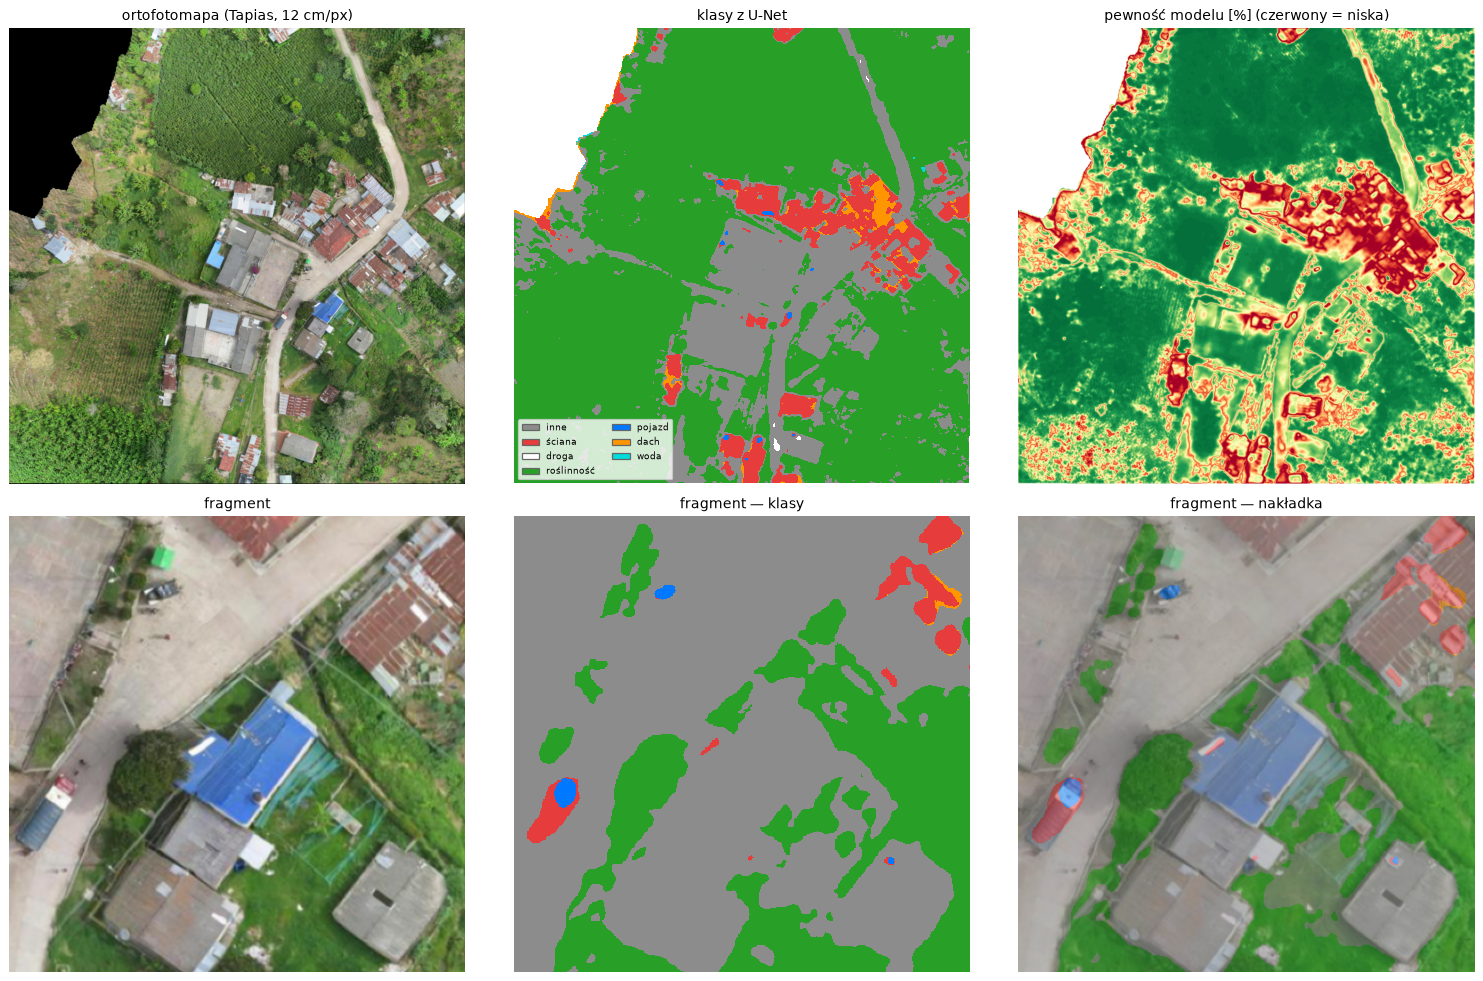

In [35]:
FRAGMENT = np.s_[850:1250, 1000:1400]                      # okolice zabudowy — ten sam kadr co w poziomie 1
paleta = ListedColormap(KOLORY_KLAS)
klasy_maska = np.ma.masked_equal(klasy, 255)

fig, ax = plt.subplots(2, 3, figsize=(17, 11), gridspec_kw={"width_ratios": [1, 1, 1]})
ax[0, 0].imshow(rgb); ax[0, 0].set_title("ortofotomapa (Tapias, 12 cm/px)")
ax[0, 1].imshow(klasy_maska, cmap=paleta, vmin=0, vmax=N_KLAS - 1, interpolation="nearest"); ax[0, 1].set_title("klasy z U-Net")
ax[0, 2].imshow(np.ma.masked_equal(pewnosc, 255), cmap="RdYlGn", vmin=40, vmax=100)
ax[0, 2].set_title("pewność modelu [%] (czerwony = niska)")
ax[1, 0].imshow(rgb[FRAGMENT]); ax[1, 0].set_title("fragment")
ax[1, 1].imshow(klasy_maska[FRAGMENT], cmap=paleta, vmin=0, vmax=N_KLAS - 1, interpolation="nearest")
ax[1, 1].set_title("fragment — klasy")
ax[1, 2].imshow(nakladka_klas(rgb[FRAGMENT], np.where(waznie, klasy, 0)[FRAGMENT], alfa=0.5).astype(np.uint8))
ax[1, 2].set_title("fragment — nakładka")
for a in ax.ravel():
    a.axis("off")
ax[0, 1].legend(handles=legenda(), loc="lower left", fontsize=7, ncol=2)
plt.tight_layout(); plt.show()